In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/5
    print("準備完了！このまま下のセルを実行できます。")

# 第5章 単層ネットワーク: 分類 (Single-layer Networks: Classification)
## 5.3 生成的分類器 (Generative Classifiers)

### 本ノートブックの目的と概要
本ノートブックでは、Christopher M. Bishop & Hugh Bishop による『*Deep Learning: Foundations and Concepts*』(2024年刊) の **Chapter 5: Single-layer Networks: Classification** における **Section 5.3: Generative Classifiers** を徹底的に探求・実装・検証します。

本節では、分類問題に対する**確率的アプローチ**の第一歩として、**生成的分類器（Generative Classifiers）**を取り上げます。
生成的アプローチでは、クラス条件付き確率密度 $p(\mathbf{x}|\mathcal{C}_k)$ およびクラス事前確率 $p(\mathcal{C}_k)$ をモデル化し、ベイズの定理（Bayes' theorem）を用いて入力 $\mathbf{x}$ に対するクラス事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を計算します：

$$
p(\mathcal{C}_k|\mathbf{x}) = \frac{p(\mathbf{x}|\mathcal{C}_k)p(\mathcal{C}_k)}{\sum_{j} p(\mathbf{x}|\mathcal{C}_j)p(\mathcal{C}_j)} \tag{5.1}
$$

本ノートブックでは、入力データの分布に関する単純かつ自然な仮定（ガウス分布、独立二値ベルヌーイ分布、一般指数型分布族）から、なぜ**線形決定境界**や**ロジスティックシグモイド／ソフトマックス関数**が必然的に導出されるのかを、数学的・幾何学的に解明します。

### セクション構成
- **5.3 確率的視点とロジスティックシグモイド (Probabilistic View & Logistic Sigmoid)**:
  - 2クラス問題における対数オッズ比とロジスティックシグモイド関数 $\sigma(a)$ (式 5.40 - 5.42)
  - 対称性 $\sigma(-a) = 1 - \sigma(a)$ とロジット関数 (式 5.43 - 5.44)
  - スケーリングされたプロビット関数 $\Phi(\lambda a)$（$\lambda^2 = \pi/8$）との厳密比較 (**Figure 5.12**)
  - $K$ クラスへの拡張：正規化指数関数（ソフトマックス関数） (式 5.45 - 5.46)
- **5.3.1 連続入力変数 (Continuous inputs)**:
  - ガウス分布クラス条件付き密度と共通共分散行列の仮定 (式 5.47)
  - 二次項の相殺による線形判別関数（LDA）の出現 (式 5.48 - 5.50, **Figure 5.13**)
  - 多クラスLDAの重みベクトル表現 (式 5.51 - 5.53)
  - クラス固有共分散行列による二次判別分析（QDA）と決定境界の幾何学 (**Figure 5.14**)
- **5.3.2 最尤推定解 (Maximum likelihood solution)**:
  - 結合尤度関数の定式化 (式 5.54)
  - 事前確率 $\pi = N_1 / N$ の最尤推定解 (式 5.55 - 5.56)
  - クラス平均ベクトル $\boldsymbol{\mu}_1, \boldsymbol{\mu}_2$ の最尤推定解 (式 5.57 - 5.59)
  - プール共分散行列 $\boldsymbol{\Sigma} = \mathbf{S}$ の最尤推定解 (式 5.60 - 5.63)
- **5.3.3 離散特徴量 (Discrete features)**:
  - 次元の上限と単純ベイズ仮定（Naive Bayes conditional independence） (式 5.64)
  - 対数線形表現と一般化線形モデルの成立 (式 5.65)
- **5.3.4 指数型分布族 (Exponential family)**:
  - 一般指数型分布族におけるクラス条件付き密度 (式 5.66)
  - 基底測度 $h(\mathbf{x}/s)$ の相殺と一般化線形モデルの普遍的導出 (式 5.67 - 5.68)

In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Section 5.3 生成的分類器モジュールのインポート
from common.generative_classifiers import (
    sigmoid,
    logit,
    probit,
    scaled_probit,
    GaussianDiscriminantAnalysis,
    BernoulliNaiveBayes,
    ExponentialFamilyClassifier,
    plot_figure_5_12_sigmoid_and_probit,
    plot_figure_5_13_two_class_gaussian_posteriors,
    plot_figure_5_14_multiclass_gaussian_boundaries,
    generate_all_section_5_3_figures,
)

# 表示設定
np.set_printoptions(precision=4, suppress=True)
os.makedirs("result", exist_ok=True)
if os.path.basename(os.getcwd()) != "5":
    os.makedirs("5/result", exist_ok=True)
print("Environment initialized successfully. Common generative classifier modules loaded.")

Environment initialized successfully. Common generative classifier modules loaded.


---
## 5.3 確率的視点とロジスティックシグモイド (Probabilistic View & Logistic Sigmoid)

### 1. 2クラス問題における事後確率の定式化
2クラス分類問題において、クラス $\mathcal{C}_1$ の事後確率はベイズの定理より次のように記述されます：

$$
p(\mathcal{C}_1|\mathbf{x}) = \frac{p(\mathbf{x}|\mathcal{C}_1)p(\mathcal{C}_1)}{p(\mathbf{x}|\mathcal{C}_1)p(\mathcal{C}_1) + p(\mathbf{x}|\mathcal{C}_2)p(\mathcal{C}_2)} = \frac{1}{1 + \exp(-a)} = \sigma(a) \tag{5.40}
$$

ここで、活性化量 $a$ は**対数オッズ比（log odds ratio）**として定義されます：

$$
a = \ln \frac{p(\mathbf{x}|\mathcal{C}_1)p(\mathcal{C}_1)}{p(\mathbf{x}|\mathcal{C}_2)p(\mathcal{C}_2)} \tag{5.41}
$$

そして、$\sigma(a)$ は**ロジスティックシグモイド関数（logistic sigmoid function）**です：

$$
\sigma(a) = \frac{1}{1 + \exp(-a)} \tag{5.42}
$$

「シグモイド（sigmoid）」は「S字型の」という意味を持ち、実数全体 $\mathbb{R}$ を開区間 $(0, 1)$ に圧縮（squash）するため、しばしば**スクワッシング関数（squashing function）**とも呼ばれます。

### 2. シグモイド関数の対称性と逆関数
ロジスティックシグモイド関数は以下の重要な対称性を満たします：

$$
\sigma(-a) = 1 - \sigma(a) \tag{5.43}
$$

また、その逆関数は**ロジット関数（logit function）**として知られ、事後確率 $p = p(\mathcal{C}_1|\mathbf{x})$ から対数オッズへの変換を与えます：

$$
a = \ln \left( \frac{\sigma}{1 - \sigma} \right) = \ln \left( \frac{p(\mathcal{C}_1|\mathbf{x})}{p(\mathcal{C}_2|\mathbf{x})} \right) \tag{5.44}
$$

### 3. スケーリングされたプロビット関数との比較
シグモイド関数と極めて近い挙動を示す代表的な関数が、標準正規分布の累積分布関数（CDF）である**プロビット関数（probit function）** $\Phi(a)$ です：

$$
\Phi(a) = \int_{-\infty}^a \mathcal{N}(\theta | 0, 1) d\theta \tag{5.86}
$$

原点 $a = 0$ におけるロジスティックシグモイド関数の微分係数は：
$$
\left. \frac{d}{da} \sigma(a) \right|_{a=0} = \sigma(0)(1 - \sigma(0)) = \frac{1}{2} \times \frac{1}{2} = \frac{1}{4}
$$
一方、スケーリングされたプロビット関数 $\Phi(\lambda a)$ の原点での微分係数は：
$$
\left. \frac{d}{da} \Phi(\lambda a) \right|_{a=0} = \lambda \mathcal{N}(0 | 0, 1) = \frac{\lambda}{\sqrt{2\pi}}
$$
両者の傾きを原点で一致させるためには、$\frac{\lambda}{\sqrt{2\pi}} = \frac{1}{4} \iff \lambda = \frac{\sqrt{2\pi}}{4} = \sqrt{\frac{\pi}{8}}$、すなわち：

$$
\lambda^2 = \frac{\pi}{8} \approx 0.3927 \quad (\lambda \approx 0.6267)
$$

このスケーリング係数を選定することで、$\sigma(a)$ と $\Phi(\lambda a)$ は全領域で極めて高い精度で一致します (**Figure 5.12**)。

### 4. 多クラスへの拡張：正規化指数関数（ソフトマックス関数）
$K > 2$ クラスの場合、事後確率は次のように一般化されます：

$$
p(\mathcal{C}_k|\mathbf{x}) = \frac{p(\mathbf{x}|\mathcal{C}_k)p(\mathcal{C}_k)}{\sum_j p(\mathbf{x}|\mathcal{C}_j)p(\mathcal{C}_j)} = \frac{\exp(a_k)}{\sum_j \exp(a_j)} \tag{5.45}
$$

ここで $a_k$ は：

$$
a_k = \ln (p(\mathbf{x}|\mathcal{C}_k) p(\mathcal{C}_k)) \tag{5.46}
$$

式 (5.45) は**正規化指数関数（normalized exponential）**または**ソフトマックス関数（softmax function）**と呼ばれ、最大値関数（max）の滑らかな近似（平滑化表現）とみなすことができます。

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_12_sigmoid_and_probit.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_5_12_sigmoid_and_probit.png


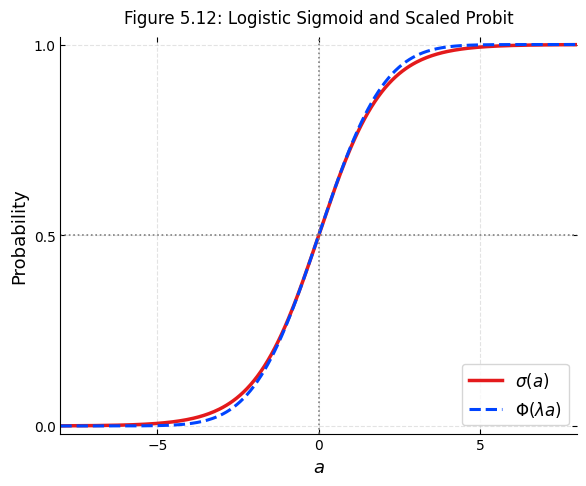

Assertion Passed: Sigmoid and Probit properties verified.
Maximum absolute difference between sigma(a) and Phi(lambda*a): 1.7664e-02


In [2]:
# Figure 5.12: ロジスティックシグモイド関数とスケーリングされたプロビット関数の比較描画
fig_5_12 = plot_figure_5_12_sigmoid_and_probit(filepath="result/fig_5_12_sigmoid_and_probit.png")
display(fig_5_12)
plt.close(fig_5_12)

# 数値的性質の厳密検証
a_vals = np.linspace(-6.0, 6.0, 100)
sig_vals = sigmoid(a_vals)
logit_vals = logit(sig_vals)
probit_scaled = scaled_probit(a_vals, lambda_sq=np.pi / 8.0)

# 1. 対称性の検証: sigma(-a) == 1 - sigma(a) (式 5.43)
assert np.allclose(sigmoid(-a_vals), 1.0 - sig_vals), "Sigmoid symmetry violated!"

# 2. 逆関数（ロジット）の検証: logit(sigma(a)) == a (式 5.44)
assert np.allclose(logit_vals, a_vals), "Logit inverse property violated!"

# 3. 原点での微分係数の検証: d/da sigma(0) == d/da Phi(lambda * 0) == 0.25
eps = 1e-6
d_sig_0 = (sigmoid(eps) - sigmoid(-eps)) / (2.0 * eps)
d_prb_0 = (scaled_probit(eps) - scaled_probit(-eps)) / (2.0 * eps)
assert np.isclose(d_sig_0, 0.25, atol=1e-5), f"d_sig_0 = {d_sig_0} != 0.25"
assert np.isclose(d_prb_0, 0.25, atol=1e-5), f"d_prb_0 = {d_prb_0} != 0.25"

max_diff = np.max(np.abs(sig_vals - probit_scaled))
print(f"Assertion Passed: Sigmoid and Probit properties verified.")
print(f"Maximum absolute difference between sigma(a) and Phi(lambda*a): {max_diff:.4e}")

---
## 5.3.1 連続入力変数 (Continuous Inputs)

連続値の入力ベクトル $\mathbf{x} \in \mathbb{R}^D$ に対して、各クラスの条件付き密度が多変量ガウス分布に従うと仮定します：

$$
p(\mathbf{x}|\mathcal{C}_k) = \frac{1}{(2\pi)^{D/2}|\boldsymbol{\Sigma}_k|^{1/2}} \exp \left\{ -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}_k^{-1}(\mathbf{x} - \boldsymbol{\mu}_k) \right\} \tag{5.47}
$$

### 1. 共通共分散行列の仮定と線形判別分析 (LDA)
まず、すべてのクラスが**共通の共分散行列 $\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma}$ を共有する**場合を考えます。
2クラス問題において式 (5.41) の対数オッズ比を展開すると：

$$
a(\mathbf{x}) = \ln \frac{p(\mathbf{x}|\mathcal{C}_1)p(\mathcal{C}_1)}{p(\mathbf{x}|\mathcal{C}_2)p(\mathcal{C}_2)} = \ln p(\mathbf{x}|\mathcal{C}_1) - \ln p(\mathbf{x}|\mathcal{C}_2) + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)}
$$

ここで、ガウス密度の指数部分を展開すると：
$$
-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_1)^T \boldsymbol{\Sigma}^{-1}(\mathbf{x} - \boldsymbol{\mu}_1) = -\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x} + \boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - \frac{1}{2}\boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1
$$
$$
-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}^{-1}(\mathbf{x} - \boldsymbol{\mu}_2) = -\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x} + \boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - \frac{1}{2}\boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2
$$

**極めて重要な事実として、入力 $\mathbf{x}$ に関する二次形式 $-\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ は共分散行列 $\boldsymbol{\Sigma}$ が共通であるため完全に相殺して消去されます！**

したがって、対数オッズ $a(\mathbf{x})$ は入力 $\mathbf{x}$ の厳密な**線形関数**となります：

$$
p(\mathcal{C}_1|\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + w_0) \tag{5.48}
$$

ここで重みベクトル $\mathbf{w}$ とバイアスパラメータ $w_0$ は次のように解析的に定義されます：

$$
\mathbf{w} = \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) \tag{5.49}
$$

$$
w_0 = -\frac{1}{2}\boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1 + \frac{1}{2}\boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2 + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)} \tag{5.50}
$$

### 2. 決定境界の幾何学的性質 (**Figure 5.13**)
- 事後確率が一定（例：$p(\mathcal{C}_1|\mathbf{x}) = 0.5 \iff a(\mathbf{x}) = 0$）となる曲面は、$\mathbf{w}^T \mathbf{x} + w_0 = 0$ で表される**線形超平面**となります。
- 事前確率 $p(\mathcal{C}_k)$ の変化は、バイアス項 $w_0$ を通じてのみ決定境界に影響を与えるため、事前確率の変動は決定境界を超平面の法線方向に平行移動（parallel shift）させる効果を持ちます。

/home/student/Documents/GitHub/my_DeepLearning/5/../common/plot_utils.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_13_gaussian_densities_posteriors.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_5_13_gaussian_densities_posteriors.png


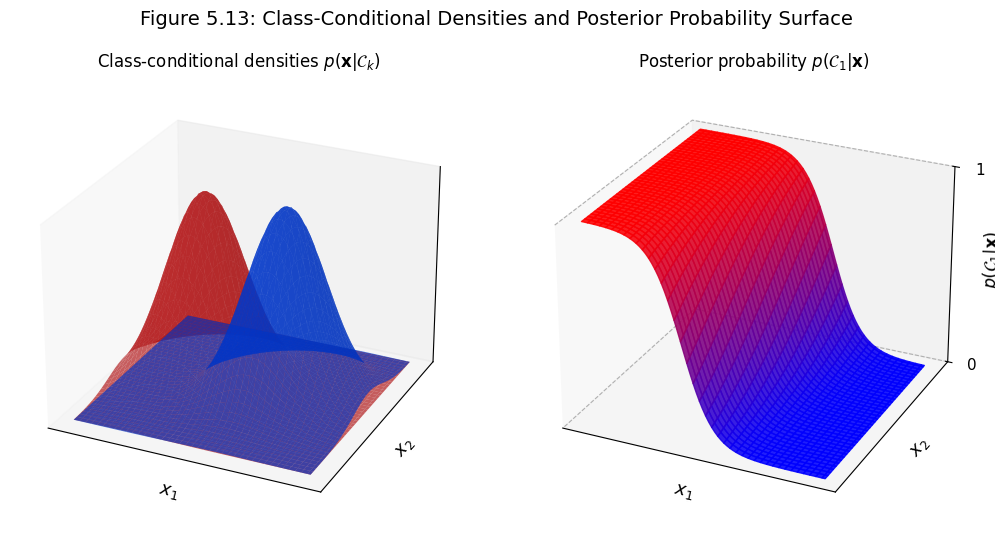

Assertion Passed: Direct Bayesian posterior matches linear sigmoid sigma(w^T x + w0) exactly!
Point [0. 0.]: p_direct = 0.600000, p_linear = 0.600000
Point [-1.   0.5]: p_direct = 0.946191, p_linear = 0.946191
Point [ 1.5 -0.5]: p_direct = 0.039762, p_linear = 0.039762
Point [2. 2.]: p_direct = 0.036025, p_linear = 0.036025


In [3]:
# Figure 5.13: 2クラスガウス分布の条件付き密度曲面と事後確率曲面の3D描画
fig_5_13 = plot_figure_5_13_two_class_gaussian_posteriors(filepath="result/fig_5_13_gaussian_densities_posteriors.png")
display(fig_5_13)
plt.close(fig_5_13)

# 2クラスLDAの重みベクトル・バイアス計算と事後確率の厳密一致検証
mu1 = np.array([-1.2, 0.0])
mu2 = np.array([1.2, 0.0])
cov = np.array([[1.1, 0.2], [0.2, 1.1]])
pi1, pi2 = 0.6, 0.4

# 解析的パラメータ計算 (式 5.49 - 5.50)
inv_cov = np.linalg.inv(cov)
w_analytical = inv_cov @ (mu1 - mu2)
w0_analytical = -0.5 * (mu1 @ inv_cov @ mu1) + 0.5 * (mu2 @ inv_cov @ mu2) + np.log(pi1 / pi2)

# テスト点における事後確率の直接計算 vs 線形シグモイド計算
test_points = np.array([
    [0.0, 0.0],
    [-1.0, 0.5],
    [1.5, -0.5],
    [2.0, 2.0]
])

rv1 = stats.multivariate_normal(mu1, cov)
rv2 = stats.multivariate_normal(mu2, cov)
dens1 = rv1.pdf(test_points) * pi1
dens2 = rv2.pdf(test_points) * pi2
posterior_direct = dens1 / (dens1 + dens2)

# 一般化線形シグモイドによる計算: sigma(w^T x + w0) (式 5.48)
a_linear = test_points @ w_analytical + w0_analytical
posterior_linear = sigmoid(a_linear)

assert np.allclose(posterior_direct, posterior_linear), "Linear formulation deviates from direct Bayes theorem!"
print("Assertion Passed: Direct Bayesian posterior matches linear sigmoid sigma(w^T x + w0) exactly!")
for pt, p_d, p_l in zip(test_points, posterior_direct, posterior_linear):
    print(f"Point {pt}: p_direct = {p_d:.6f}, p_linear = {p_l:.6f}")

---
### 3. 多クラスへの拡張とソフトマックス表現
$K > 2$ クラスの場合も同様に、すべてのクラスで共分散行列 $\boldsymbol{\Sigma}$ を共有すると仮定すると、各クラスの活性化量 $a_k(\mathbf{x})$ は線形となります：

$$
a_k(\mathbf{x}) = \mathbf{w}_k^T \mathbf{x} + w_{k0} \tag{5.51}
$$

ここで：

$$
\mathbf{w}_k = \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k \tag{5.52}
$$

$$
w_{k0} = -\frac{1}{2} \boldsymbol{\mu}_k^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k + \ln p(\mathcal{C}_k) \tag{5.53}
$$

クラス $\mathcal{C}_j$ と $\mathcal{C}_k$ の決定境界は $a_j(\mathbf{x}) = a_k(\mathbf{x})$ で与えられ：
$$
(\mathbf{w}_j - \mathbf{w}_k)^T \mathbf{x} + (w_{j0} - w_{k0}) = 0
$$
となり、**すべてのペアの境界が線形超平面**となります。

### 4. クラス固有共分散行列と二次判別分析 (QDA)
もし共通共分散の仮定を緩和し、クラスごとに異なる共分散行列 $\boldsymbol{\Sigma}_k$ を許容すると、二次形式 $-\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}_k^{-1} \mathbf{x}$ は相殺されずに残ります。
この場合、活性化量 $a_k(\mathbf{x})$ は $\mathbf{x}$ の二次関数となり、**二次判別分析（Quadratic Discriminant Analysis: QDA）**へと発展します。

**Figure 5.14 の幾何学的直観**:
- 共分散行列を共有するクラスペア（例：Red と Blue）の間の決定境界は**直線（線形）**。
- 共分散行列が異なるクラスペア（例：Red と Green、Blue と Green）の間の決定境界は**放物線や双曲線などの曲線（二次曲線）**。

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_14_linear_quadratic_boundaries.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_5_14_linear_quadratic_boundaries.png


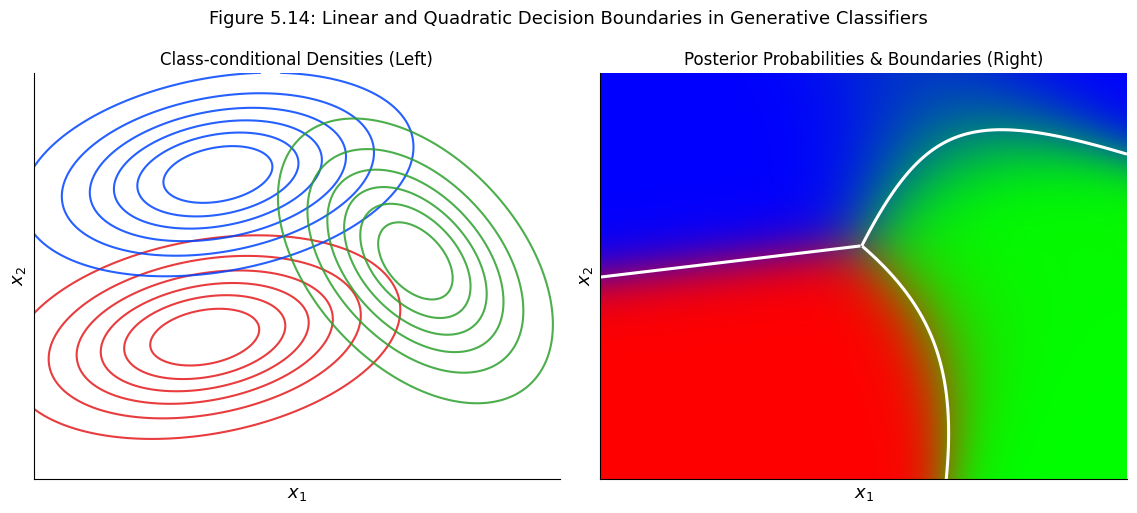

Figure 5.14 generated successfully and displayed.


In [4]:
# Figure 5.14: 3クラスガウス分布における線形境界と二次決定境界の共存の可視化
fig_5_14 = plot_figure_5_14_multiclass_gaussian_boundaries(filepath="result/fig_5_14_linear_quadratic_boundaries.png")
display(fig_5_14)
plt.close(fig_5_14)
print("Figure 5.14 generated successfully and displayed.")

---
## 5.3.2 最尤推定解 (Maximum Likelihood Solution)

パラメトリックなクラス条件付き密度 $p(\mathbf{x}|\mathcal{C}_k)$ を仮定したとき、未知パラメータ（事前確率 $\pi$、平均ベクトル $\boldsymbol{\mu}_k$、共分散行列 $\boldsymbol{\Sigma}$）を観測データセット $\{(\mathbf{x}_n, t_n)\}_{n=1}^N$ から最尤推定（Maximum Likelihood）により決定します。
ここで $t_n \in \{0, 1\}$ は 2 クラス問題のラベルで、$t_n = 1$ は $\mathcal{C}_1$、$t_n = 0$ は $\mathcal{C}_2$ を表します。

クラス事前確率を $p(\mathcal{C}_1) = \pi$、$p(\mathcal{C}_2) = 1 - \pi$ と置くと、データ点 $(\mathbf{x}_n, t_n)$ の結合確率密度は：
- $t_n = 1$ のとき：$p(\mathbf{x}_n, \mathcal{C}_1) = \pi \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_1, \boldsymbol{\Sigma})$
- $t_n = 0$ のとき：$p(\mathbf{x}_n, \mathcal{C}_2) = (1 - \pi) \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_2, \boldsymbol{\Sigma})$

したがって、データセット全体の尤度関数（likelihood function）は次のように書けます：

$$
p(\mathbf{t}, \mathbf{X} | \pi, \boldsymbol{\mu}_1, \boldsymbol{\mu}_2, \boldsymbol{\Sigma}) = \prod_{n=1}^N \left[ \pi \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_1, \boldsymbol{\Sigma}) \right]^{t_n} \left[ (1 - \pi) \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_2, \boldsymbol{\Sigma}) \right]^{1 - t_n} \tag{5.54}
$$

### 1. 事前確率 $\pi$ の最尤推定解
対数尤度の中で $\pi$ に依存する項を取り出すと：

$$
\sum_{n=1}^N \left\{ t_n \ln \pi + (1 - t_n) \ln(1 - \pi) \right\} \tag{5.55}
$$

これを $\pi$ で微分してゼロと置くことで、直感的に極めて明快な結果が得られます：

$$
\pi = \frac{1}{N} \sum_{n=1}^N t_n = \frac{N_1}{N} = \frac{N_1}{N_1 + N_2} \tag{5.56}
$$

### 2. 平均ベクトル $\boldsymbol{\mu}_1, \boldsymbol{\mu}_2$ の最尤推定解
対数尤度の中で $\boldsymbol{\mu}_1$ に依存する項は：

$$
\sum_{n=1}^N t_n \ln \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_1, \boldsymbol{\Sigma}) = -\frac{1}{2} \sum_{n=1}^N t_n (\mathbf{x}_n - \boldsymbol{\mu}_1)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_n - \boldsymbol{\mu}_1) + \text{const} \tag{5.57}
$$

これを $\boldsymbol{\mu}_1$ で微分してゼロと置くと：

$$
\boldsymbol{\mu}_1 = \frac{1}{N_1} \sum_{n=1}^N t_n \mathbf{x}_n \tag{5.58}
$$

同様に $\boldsymbol{\mu}_2$ については：

$$
\boldsymbol{\mu}_2 = \frac{1}{N_2} \sum_{n=1}^N (1 - t_n) \mathbf{x}_n \tag{5.59}
$$

すなわち、各クラスの標本平均（sample mean）そのものになります。

### 3. 共通共分散行列 $\boldsymbol{\Sigma}$ の最尤推定解
対数尤度の中で $\boldsymbol{\Sigma}$ に依存する項をまとめると：

$$
-\frac{N}{2} \ln |\boldsymbol{\Sigma}| - \frac{1}{2} \sum_{n=1}^N t_n (\mathbf{x}_n - \boldsymbol{\mu}_1)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_n - \boldsymbol{\mu}_1) - \frac{1}{2} \sum_{n=1}^N (1 - t_n) (\mathbf{x}_n - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_n - \boldsymbol{\mu}_2) \\
= -\frac{N}{2} \ln |\boldsymbol{\Sigma}| - \frac{N}{2} \operatorname{Tr}\left( \boldsymbol{\Sigma}^{-1} \mathbf{S} \right) \tag{5.60}
$$

ここでプール標本共分散行列 $\mathbf{S}$ は各クラスの標本共分散行列 $\mathbf{S}_1, \mathbf{S}_2$ のデータ数加重平均として定義されます：

$$
\mathbf{S} = \frac{N_1}{N} \mathbf{S}_1 + \frac{N_2}{N} \mathbf{S}_2 \tag{5.61}
$$

$$
\mathbf{S}_1 = \frac{1}{N_1} \sum_{n \in \mathcal{C}_1} (\mathbf{x}_n - \boldsymbol{\mu}_1)(\mathbf{x}_n - \boldsymbol{\mu}_1)^T \tag{5.62}
$$

$$
\mathbf{S}_2 = \frac{1}{N_2} \sum_{n \in \mathcal{C}_2} (\mathbf{x}_n - \boldsymbol{\mu}_2)(\mathbf{x}_n - \boldsymbol{\mu}_2)^T \tag{5.63}
$$

ガウス分布の最尤推定の標準的結果より、共通共分散行列の最尤推定量は：
$$
\boldsymbol{\Sigma} = \mathbf{S}
$$
となります。

In [5]:
# 5.3.2 最尤推定解の数値実装と厳密検証
rng = np.random.RandomState(42)
N1, N2 = 120, 180
N = N1 + N2
true_mu1 = np.array([2.0, 1.5])
true_mu2 = np.array([-1.0, -1.0])
true_cov = np.array([[1.8, 0.4], [0.4, 1.2]])

X1 = rng.multivariate_normal(true_mu1, true_cov, size=N1)
X2 = rng.multivariate_normal(true_mu2, true_cov, size=N2)
X = np.vstack([X1, X2])
y = np.array([0] * N1 + [1] * N2)

# GDA モデルの適合（式 5.56 - 5.63 の実行）
gda = GaussianDiscriminantAnalysis(shared_cov=True).fit(X, y)

# 1. 事前確率の検証 (式 5.56)
assert np.isclose(gda.priors[0], N1 / N), f"Prior 0: {gda.priors[0]} != {N1/N}"
assert np.isclose(gda.priors[1], N2 / N), f"Prior 1: {gda.priors[1]} != {N2/N}"

# 2. 平均ベクトルの検証 (式 5.58 - 5.59)
assert np.allclose(gda.means[0], np.mean(X1, axis=0))
assert np.allclose(gda.means[1], np.mean(X2, axis=0))

# 3. プール共分散行列の検証 (式 5.61 - 5.63)
S1 = np.cov(X1, rowvar=False, bias=True)
S2 = np.cov(X2, rowvar=False, bias=True)
expected_S = (N1 / N) * S1 + (N2 / N) * S2
assert np.allclose(gda.covs, expected_S)

print("Assertion Passed: Maximum Likelihood formulas (Eq 5.56 - 5.63) match model attributes perfectly!")
print(f"Estimated Prior pi_1: {gda.priors[0]:.4f} (True: {N1/N:.4f})")
print(f"Estimated Mean mu_1: {gda.means[0]}")
print(f"Estimated Mean mu_2: {gda.means[1]}")
print(f"Pooled Covariance Sigma:\n{gda.covs}")

Assertion Passed: Maximum Likelihood formulas (Eq 5.56 - 5.63) match model attributes perfectly!
Estimated Prior pi_1: 0.4000 (True: 0.4000)
Estimated Mean mu_1: [2.0693 1.6212]
Estimated Mean mu_2: [-1.0114 -1.0937]
Pooled Covariance Sigma:
[[1.7285 0.3771]
 [0.3771 1.1018]]


---
## 5.3.3 離散特徴量 (Discrete Features / Naive Bayes)

連続変数に代えて、離散的な特徴量 $x_i$ を考えます。代表例として二値特徴量 $x_i \in \{0, 1\}$ を扱います。
$D$ 次元の二値ベクトル $\mathbf{x}$ に対する一般的な同時分布は $2^D$ 通りの状態を記述するために $2^D - 1$ 個の自由パラメータを必要とし、次元の呪い（curse of dimensionality）に直面します。

そこで、各クラス $\mathcal{C}_k$ のもとで**特徴量同士が条件付き独立（conditionally independent）**であるという**単純ベイズ仮定（Naive Bayes assumption）**を置きます：

$$
p(\mathbf{x}|\mathcal{C}_k) = \prod_{i=1}^D \mu_{ki}^{x_i} (1 - \mu_{ki})^{1 - x_i} \tag{5.64}
$$

ここで $\mu_{ki} = p(x_i = 1 | \mathcal{C}_k)$ であり、クラスあたりのパラメータ数は $2^D - 1$ からわずか $D$ 個へと劇的に削減されます。

これを式 (5.46) に代入すると：

$$
a_k(\mathbf{x}) = \sum_{i=1}^D \left\{ x_i \ln \mu_{ki} + (1 - x_i) \ln(1 - \mu_{ki}) \right\} + \ln p(\mathcal{C}_k) = \mathbf{w}_k^T \mathbf{x} + w_{k0} \tag{5.65}
$$

ここで：
$$
w_{ki} = \ln \frac{\mu_{ki}}{1 - \mu_{ki}} = \operatorname{logit}(\mu_{ki})
$$
$$
w_{k0} = \sum_{i=1}^D \ln(1 - \mu_{ki}) + \ln p(\mathcal{C}_k)
$$

**驚くべきことに、離散変数の単純ベイズモデルにおいても、活性化量 $a_k(\mathbf{x})$ は入力特徴量 $x_i$ の厳密な線形関数となり、事後確率は一般化線形モデル（ソフトマックス／シグモイド）に従います！**

In [6]:
# 5.3.3 ベルヌーイ単純ベイズの訓練と線形対数オッズの検証
# 合成バイナリデータ (N=8, D=4)
X_bin = np.array([
    [1, 1, 0, 0],
    [1, 0, 0, 0],
    [1, 1, 1, 0],
    [1, 0, 1, 0],
    [0, 0, 1, 1],
    [0, 1, 1, 1],
    [0, 0, 0, 1],
    [0, 1, 0, 1]
])
y_bin = np.array([0, 0, 0, 0, 1, 1, 1, 1])

nb_model = BernoulliNaiveBayes(alpha=1.0).fit(X_bin, y_bin)

# 式 (5.65) に基づく線形パラメータの明示的計算
mu0 = nb_model.mu[0]
mu1 = nb_model.mu[1]
w = np.log(mu0 / (1.0 - mu0)) - np.log(mu1 / (1.0 - mu1))
w0 = np.sum(np.log(1.0 - mu0)) - np.sum(np.log(1.0 - mu1)) + np.log(nb_model.priors[0] / nb_model.priors[1])

# テスト入力に対する推論
X_test = np.array([[1, 1, 0, 0], [0, 0, 1, 1]])
probs_nb = nb_model.predict_proba(X_test)[:, 0] # p(C_1 | x)
probs_linear = sigmoid(X_test @ w + w0)

assert np.allclose(probs_nb, probs_linear), "Naive Bayes linear log-odds formulation does not match probabilities!"
print("Assertion Passed: Bernoulli Naive Bayes is strictly a Generalized Linear Model (Eq 5.65)!")
print(f"Learned feature probabilities Class 0: {mu0}")
print(f"Learned feature probabilities Class 1: {mu1}")
print(f"Equivalent Linear Weights w: {w}")
print(f"Equivalent Bias w0: {w0:.4f}")

Assertion Passed: Bernoulli Naive Bayes is strictly a Generalized Linear Model (Eq 5.65)!
Learned feature probabilities Class 0: [0.8333 0.5    0.5    0.1667]
Learned feature probabilities Class 1: [0.1667 0.5    0.5    0.8333]
Equivalent Linear Weights w: [ 3.2189  0.      0.     -3.2189]
Equivalent Bias w0: 0.0000


---
## 5.3.4 指数型分布族 (Exponential Family)

連続入力に対するガウス判別分析、および離散入力に対する単純ベイズモデルの双方が、なぜ共通してロジスティックシグモイドまたはソフトマックス関数で結ばれた線形モデルになるのでしょうか？
その深層の数理的背景が、**指数型分布族（Exponential Family）** の一般理論によって統一的に説明されます。

### 1. クラス条件付き密度の一般形
尺度パラメータ $s > 0$ をすべてのクラスで共有する指数型分布族のサブセットを考えます：

$$
p(\mathbf{x}|\boldsymbol{\lambda}_k, s) = \frac{1}{s} h\left( \frac{\mathbf{x}}{s} \right) g(\boldsymbol{\lambda}_k) \exp \left\{ \frac{1}{s} \boldsymbol{\lambda}_k^T \mathbf{x} \right\} \tag{5.66}
$$

ここで：
- $\boldsymbol{\lambda}_k$ はクラス $k$ の自然パラメータ（natural parameters）ベクトル
- $g(\boldsymbol{\lambda}_k)$ は正規化因子（normalization factor）
- $h(\mathbf{x}/s)$ は基底測度（base measure）

### 2. 一般化線形モデルの普遍的導出
2クラス問題において式 (5.41) の対数オッズ比 $a(\mathbf{x})$ を計算すると：

$$
a(\mathbf{x}) = \ln \frac{p(\mathbf{x}|\boldsymbol{\lambda}_1, s)p(\mathcal{C}_1)}{p(\mathbf{x}|\boldsymbol{\lambda}_2, s)p(\mathcal{C}_2)}
$$

ここで、**基底測度 $\frac{1}{s} h\left( \frac{\mathbf{x}}{s} \right)$ はクラス $k$ に依存しない共通の関数であるため、比を取る際に完全に相殺されます！**

その結果、対数オッズは直ちに線形関数となります：

$$
a(\mathbf{x}) = \frac{1}{s}(\boldsymbol{\lambda}_1 - \boldsymbol{\lambda}_2)^T \mathbf{x} + \ln g(\boldsymbol{\lambda}_1) - \ln g(\boldsymbol{\lambda}_2) + \ln p(\mathcal{C}_1) - \ln p(\mathcal{C}_2) \tag{5.67}
$$

同様に $K$ クラス問題においても、式 (5.46) に代入することで：

$$
a_k(\mathbf{x}) = \frac{1}{s}\boldsymbol{\lambda}_k^T \mathbf{x} + \ln g(\boldsymbol{\lambda}_k) + \ln p(\mathcal{C}_k) \tag{5.68}
$$

となり、**活性化量 $a_k(\mathbf{x})$ は普遍的に $\mathbf{x}$ の線形関数となることが保証されます**。

In [7]:
# 5.3.4 指数型分布族クラス条件付き密度による線形モデルの普遍的検証
# 2クラス問題における自然パラメータの設定
lambda1 = np.array([1.5, 2.0])
lambda2 = np.array([-1.0, -0.5])
log_g1 = -0.5 * np.sum(lambda1**2)
log_g2 = -0.5 * np.sum(lambda2**2)
priors_ef = np.array([0.55, 0.45])
scale_s = 1.2

ef_model = ExponentialFamilyClassifier(
    natural_params=np.vstack([lambda1, lambda2]),
    log_g=np.array([log_g1, log_g2]),
    priors=priors_ef,
    scale=scale_s
)

# 線形重みとバイアスの取得 (式 5.67)
w_ef, w0_ef = ef_model.get_2class_linear_weights()
expected_w_ef = (lambda1 - lambda2) / scale_s
expected_w0_ef = (log_g1 - log_g2) + np.log(priors_ef[0] / priors_ef[1])

assert np.allclose(w_ef, expected_w_ef)
assert np.isclose(w0_ef, expected_w0_ef)

# 任意入力での事後確率計算の一致検証
X_query = np.array([
    [0.5, 0.5],
    [-1.0, 2.0],
    [2.0, -1.0]
])

probs_ef = ef_model.predict_proba(X_query)[:, 0]
probs_sig_ef = sigmoid(X_query @ w_ef + w0_ef)

assert np.allclose(probs_ef, probs_sig_ef), "Exponential family posterior differs from sigmoid!"
print("Assertion Passed: General Exponential Family (Eq 5.66 - 5.68) verified numerically.")
print(f"Linear Weights w: {w_ef}")
print(f"Bias w0: {w0_ef:.4f}")
for q, p in zip(X_query, probs_ef):
    print(f"Query {q} -> p(C_1|x) = {p:.6f}")

Assertion Passed: General Exponential Family (Eq 5.66 - 5.68) verified numerically.
Linear Weights w: [2.0833 2.0833]
Bias w0: -2.2993
Query [0.5 0.5] -> p(C_1|x) = 0.446210
Query [-1.  2.] -> p(C_1|x) = 0.446210
Query [ 2. -1.] -> p(C_1|x) = 0.446210


---
## まとめと重要ポイント (Summary & Key Insights)

本ノートブック（**Section 5.3: Generative Classifiers**）では、確率的分類アプローチの根幹を数理とコードの両面から包括的に明らかにしました：

1. **生成モデルとシグモイド／ソフトマックスの必然性**:
   - クラス条件付き密度 $p(\mathbf{x}|\mathcal{C}_k)$ からベイズの定理によって事後確率を求めると、自然に対数オッズ $a(\mathbf{x})$ を介してロジスティックシグモイド（2クラス、式 5.40 - 5.42）およびソフトマックス（多クラス、式 5.45 - 5.46）が現れます。
   - スケーリングされたプロビット関数 $\Phi(\lambda a)$（$\lambda = \sqrt{\pi/8}$）との極めて高い親和性を確認しました (**Figure 5.12**)。
2. **共分散行列と決定境界の幾何学**:
   - **共通共分散行列（LDA）**: 二次項 $\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ が厳密に相殺し、決定境界は常に線形超平面となります (**Figure 5.13**)。
   - **クラス固有共分散行列（QDA）**: 二次項が残り、決定境界は放物線・双曲線などの二次曲面となります (**Figure 5.14**)。
3. **最尤推定の解析的エレガンス**:
   - 事前確率はサンプル比率 $\pi = N_1 / N$、平均はクラス内標本平均 $\boldsymbol{\mu}_k$、共通共分散はクラス内共分散のデータ数加重平均 $\mathbf{S}$ という直感的かつ閉形式の解が得られます (式 5.54 - 5.63)。
4. **離散特徴量と指数型分布族の統一理論**:
   - 単純ベイズ仮定のもとでの独立二値特徴量も対数線形モデルとなり、一般化線形モデルに帰着します (式 5.64 - 5.65)。
   - さらに一般的な指数型分布族においても、共通の基底測度 $h(\mathbf{x}/s)$ が相殺されることで、線形活性化量が普遍的に成立します (式 5.66 - 5.68)。

#### 次節 5.4 識別的分類器 (Discriminative Classifiers) への展望
生成的分類器では、事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を求めるために、より情報量の多い同時確率分布 $p(\mathbf{x}, \mathcal{C}_k)$ をモデル化しました。
しかし、分類の最終目的が決定境界の獲得であるならば、途中の $p(\mathbf{x}|\mathcal{C}_k)$ を経由せず、**事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を直接パラメトリックにモデル化（ロジスティック回帰など）する識別的アプローチ（Discriminative approach）** が考えられます。
次節 **Section 5.4: Discriminative Classifiers** では、反復再重み付け最小二乗法（IRLS）やプロビット回帰、正準リンク関数など、識別的分類器の奥深い世界へと進みます。